In [ ]:
!pip install torchvision torch

In [ ]:
!pip install efficientnet_pytorch

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=31f13d35904d8bfecca1108031fd59375beb3661572911c2705d71b325d8ea97
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet_pytorch


In [ ]:
import torch
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
from google.colab import drive, runtime
import os
drive.mount('/content/drive') # Mount Google Drive


Mounted at /content/drive


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)   # should print: cuda

cuda


In [ ]:
# -------------------------------------------------------
# Configuration
# -------------------------------------------------------

MODEL_NAME = "efficientnet-b4"
PROJECT_PATH = "/content/drive/MyDrive/CS5787_DL_Final_Project"
DATA_DIR_NONBINARY = os.path.join(PROJECT_PATH, "data/Yummly-66K/food_min/split_images")
DATA_DIR_BINARY = os.path.join(PROJECT_PATH, "data/Yummly-66K/food_min/region_split_images")
SAVE_PATH = os.path.join(PROJECT_PATH, "models", "efficientnet_region_custom.pth")

In [ ]:
import torch
import torchvision.models as models
from torch import nn, optim
from efficientnet_pytorch import EfficientNet
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# -------------------------------------------------------
# Load saved model
# -------------------------------------------------------
BATCH_SIZE = 64

# Reference for test_tf:
# train_tf = transforms.Compose([
#     transforms.RandomResizedCrop(380),
#     transforms.RandomHorizontalFlip(),
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     )
# ])

test_tf = transforms.Compose([
    transforms.Resize(420),
    transforms.CenterCrop(380),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
test_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR_BINARY, "test"), test_tf)
test_loader   = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=4)

num_classes = len(test_dataset.classes)
print("Classes:", test_dataset.classes)

model = EfficientNet.from_pretrained(MODEL_NAME)

in_features = model._fc.in_features
model._fc = nn.Linear(in_features, num_classes)  # Replace final layer

state_dict = torch.load(SAVE_PATH)
model.load_state_dict(state_dict)

model = model.to(device)

Classes: ['Eastern', 'Western']
Loaded pretrained weights for efficientnet-b4


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        """
        model: trained model
        target_layer: conv layer to inspect (e.g., model._conv_head)
        """
        self.model = model
        self.model.eval()
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.fwd_handle = self.target_layer.register_forward_hook(self._forward_hook)
        self.bwd_handle = self.target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        # Save feature maps
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        # Save gradients of the target layer
        self.gradients = grad_output[0].detach()

    def generate_cam(self, input_tensor, class_idx=None):
        """
        input_tensor: shape [1, 3, H, W] on device
        class_idx: target class index; if None, use argmax
        returns: Grad-CAM heatmap as numpy array (H_feat, W_feat), normalized 0–1
        """
        self.model.zero_grad()
        output = self.model(input_tensor)  # [1, num_classes]

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        target = output[0, class_idx]
        target.backward()

        # activations: [1, C, H, W]
        # gradients:   [1, C, H, W]
        grads = self.gradients[0]      # [C, H, W]
        acts = self.activations[0]     # [C, H, W]

        # Global average pooling on gradients -> weights
        weights = grads.mean(dim=(1, 2))  # [C]

        # Weighted sum of activations
        cam = torch.zeros(acts.shape[1:], dtype=torch.float32, device=acts.device)  # [H, W]
        for i, w in enumerate(weights):
            cam += w * acts[i, :, :]

        cam = torch.relu(cam)

        # Normalize to 0–1
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.cpu().numpy()

    def remove_hooks(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

In [ ]:
grad_cam = GradCAM(model, target_layer=model._conv_head)

In [ ]:
# Same stats as the original transform
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    """
    tensor: [3, H, W], normalized
    returns: [H, W, 3] in [0,1]
    """
    x = tensor.detach().cpu().numpy()
    x = np.transpose(x, (1, 2, 0))  # CHW -> HWC
    x = x * IMAGENET_STD + IMAGENET_MEAN
    x = np.clip(x, 0, 1)
    return x


def overlay_cam_on_image(img, cam, alpha=0.5):
    """
    img: [H, W, 3] in [0,1]
    cam: [H_feat, W_feat] in [0,1] (will be resized to H,W)
    alpha: blending factor for heatmap
    """
    h, w, _ = img.shape

    # Resize CAM to image size
    cam_img = Image.fromarray((cam * 255).astype(np.uint8)).resize((w, h), resample=Image.BILINEAR)
    cam_img = np.array(cam_img) / 255.0  # [H, W]

    # Use matplotlib colormap
    cmap = plt.get_cmap('jet')
    heatmap = cmap(cam_img)[..., :3]  # [H, W, 3]

    overlay = heatmap * alpha + img * (1 - alpha)
    overlay = np.clip(overlay, 0, 1)
    return overlay

In [ ]:
# -------------------------------------------------------
# Create Grad-CAM overlay for 4 cases
# -------------------------------------------------------

model.to(device)
model.eval()

EE = "ee" # True=Eastern, Pred=Eastern
WW = "ww" # True=Western, Pred=Western
EW = "ew"
WE = "we"
img_overlays = {EE:[], WW: [], EW: [], WE: []}
num_show = 6

EASTERN = "Eastern"
WESTERN = "Western"

def buckets_full():
    # Need at least num_show in each bucket
    return all(len(lst) >= num_show for lst in img_overlays.values())

def gen_img_overlay(img_tensor, grad_cam):

    # Forward + Grad-CAM
    cam = grad_cam.generate_cam(img_tensor)

    # Denormalize image for visualization
    img = denormalize(images[i])

    # Overlay CAM
    overlay = overlay_cam_on_image(img, cam, alpha=0.5)

    return (img, overlay)


for images, labels in test_loader:
    if buckets_full():
        break

    images = images.to(device)
    labels = labels.to(device)

    for i in range(len(images)):
        if buckets_full():
            break

        img_tensor = images[i].unsqueeze(0)  # [1, 3, H, W]

        with torch.no_grad():
            logits = model(img_tensor)
            pred_idx = logits.argmax(dim=1).item()

        pred_class = test_dataset.classes[pred_idx]
        true_class = test_dataset.classes[labels[i].item()]

        if pred_class == true_class:
            if true_class == EASTERN and len(img_overlays[EE]) < num_show:
                img_overlays[EE].append(gen_img_overlay(img_tensor, grad_cam))
            elif len(img_overlays[WW]) < num_show:
                img, overlay = gen_img_overlay(img_tensor, grad_cam)
                img_overlays[WW].append(gen_img_overlay(img_tensor, grad_cam))
        else:
            if true_class == EASTERN and len(img_overlays[EW]) < num_show:
                img, overlay = gen_img_overlay(img_tensor, grad_cam)
                img_overlays[EW].append(gen_img_overlay(img_tensor, grad_cam))
            elif len(img_overlays[WE]) < num_show:
                img, overlay = gen_img_overlay(img_tensor, grad_cam)
                img_overlays[WE].append(gen_img_overlay(img_tensor, grad_cam))

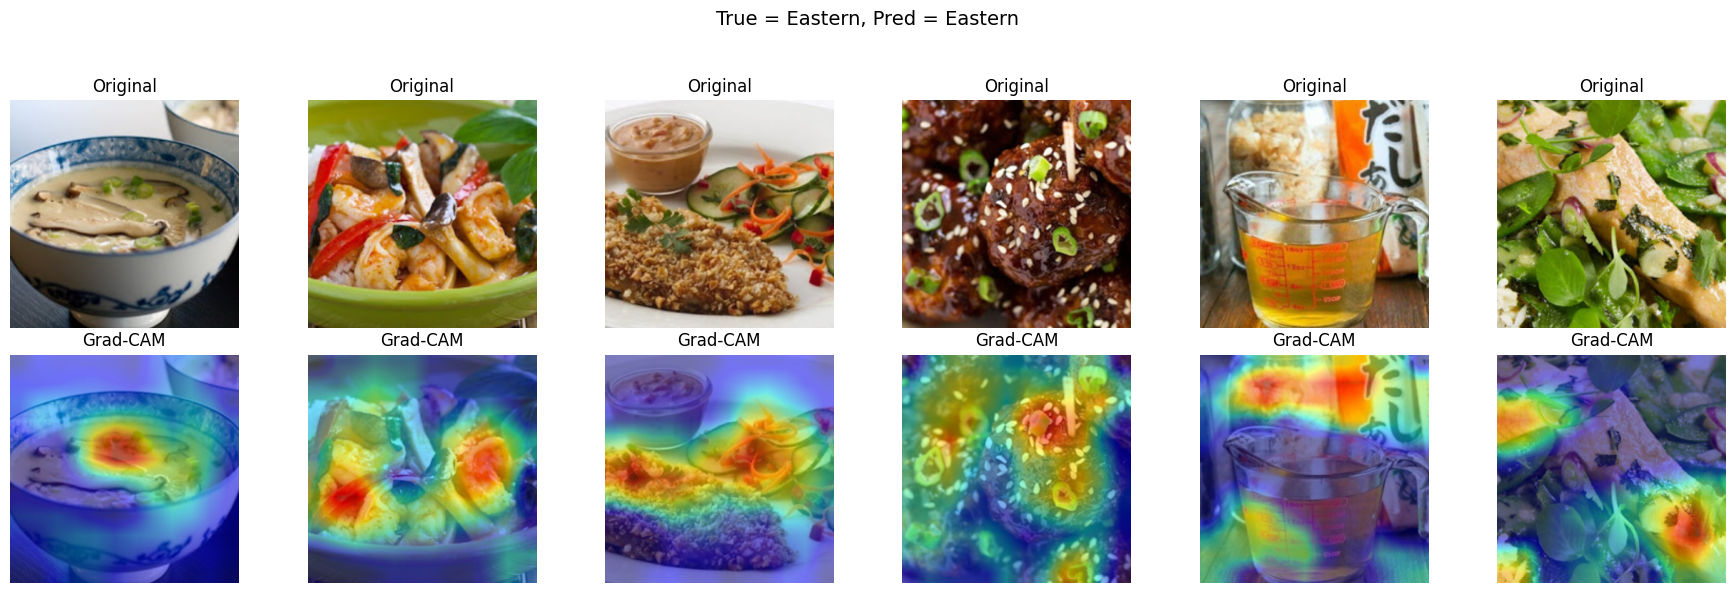

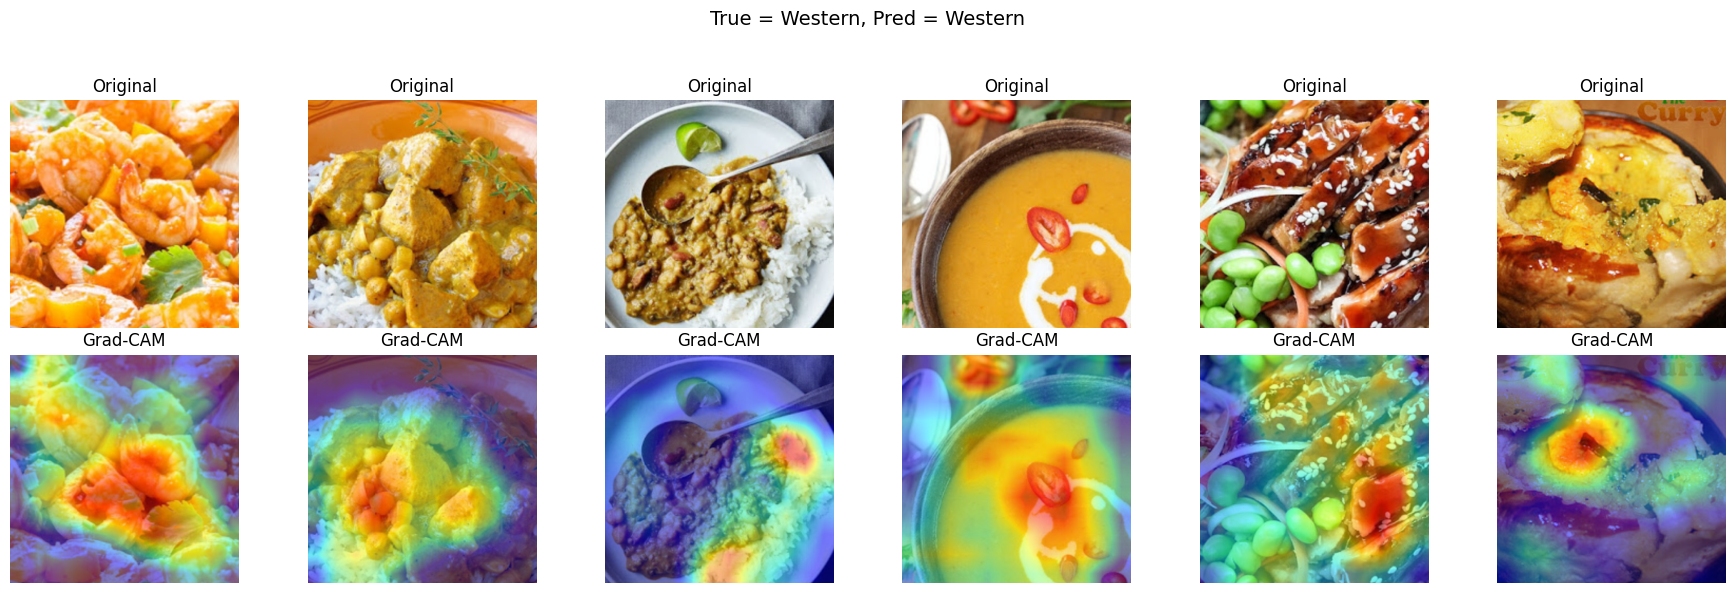

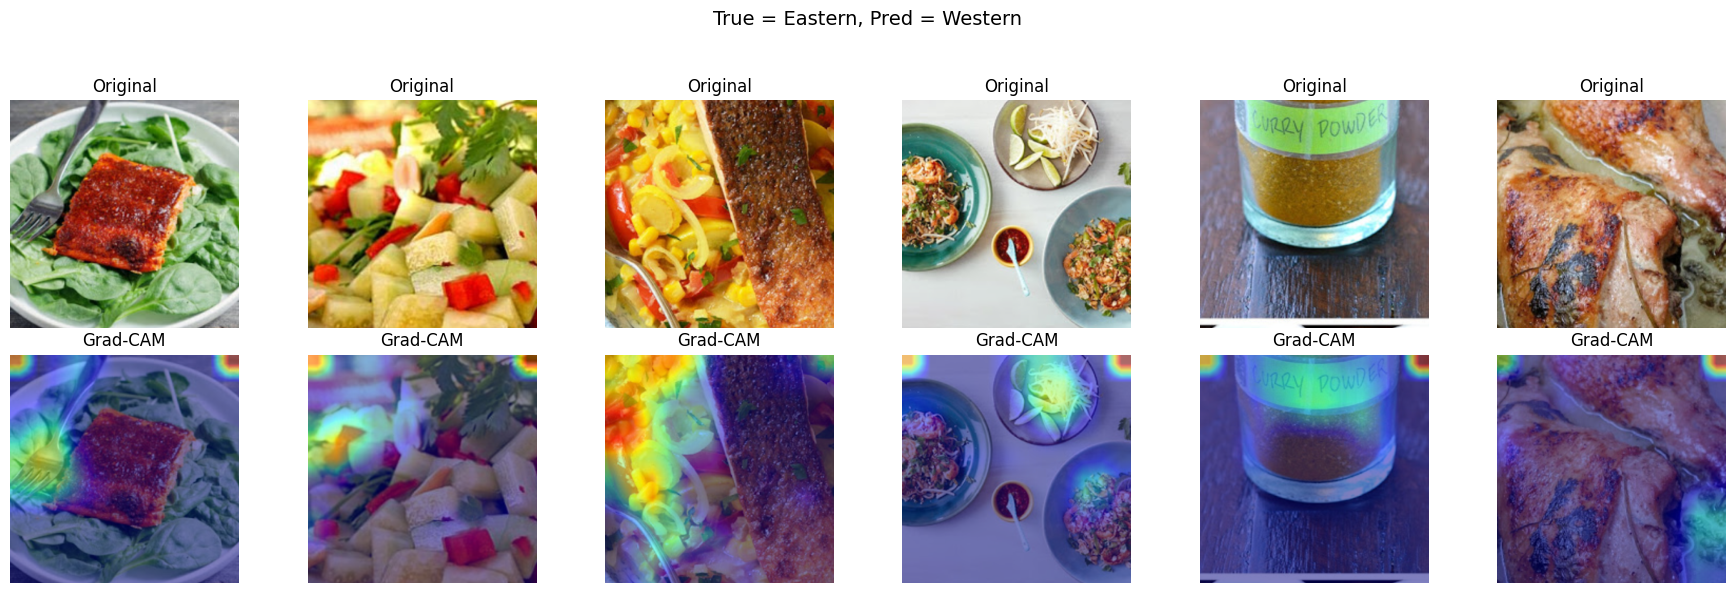

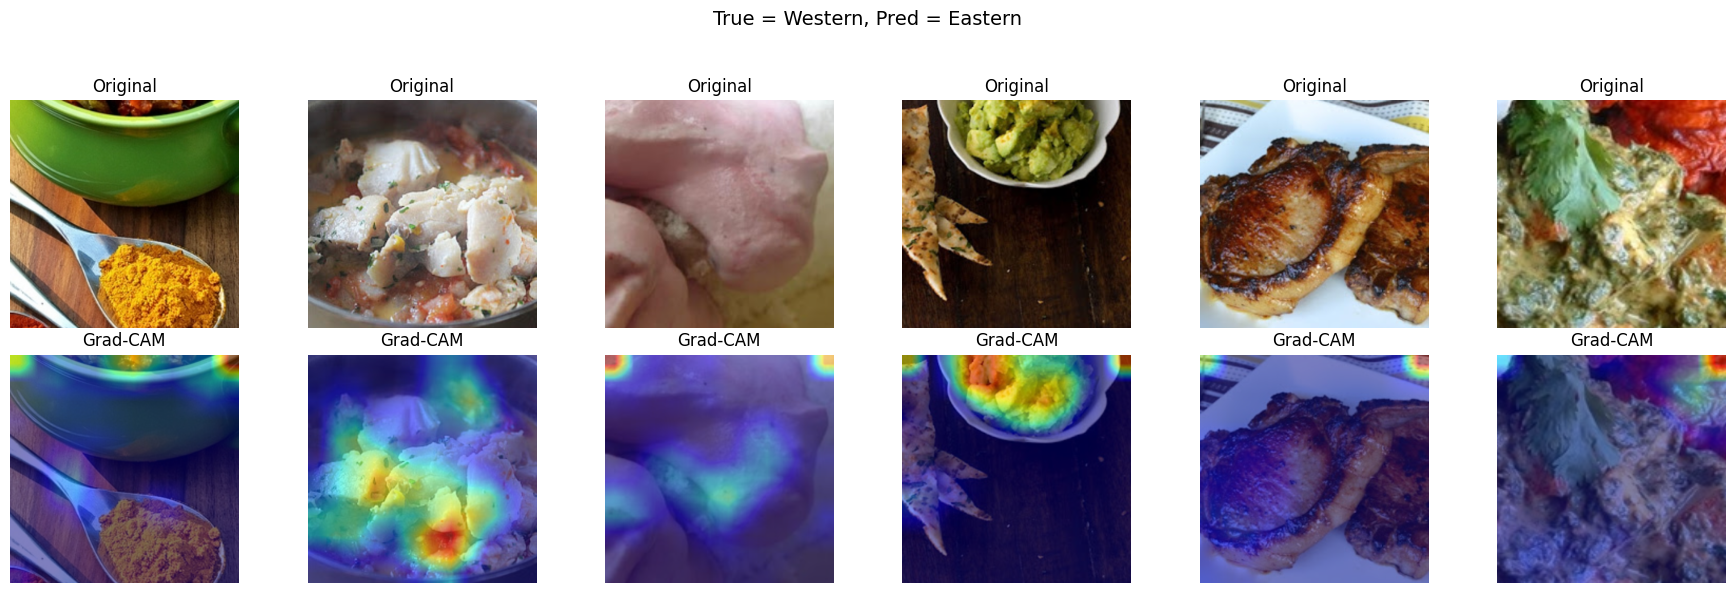

In [ ]:
# -------------------------------------------------------
# Display Grad-CAM overlay for 4 cases
# -------------------------------------------------------

import matplotlib.pyplot as plt

case_titles = {
    EE: "True = Eastern, Pred = Eastern",
    WW: "True = Western, Pred = Western",
    EW: "True = Eastern, Pred = Western",
    WE: "True = Western, Pred = Eastern",
}

# One figure per case: EE, WW, EW, WE
for case_key in [EE, WW, EW, WE]:
    samples = img_overlays[case_key]

    if len(samples) == 0:
        print(f"No samples for case {case_key}, skipping.")
        continue

    n = min(num_show, len(samples))

    plt.figure(figsize=(3 * n, 6))
    plt.suptitle(case_titles[case_key], fontsize=14)

    for i, (img, overlay) in enumerate(samples[:n]):
        # Original image
        plt.subplot(2, n, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title("Original")

        # Grad-CAM overlay
        plt.subplot(2, n, n + i + 1)
        plt.imshow(overlay)
        plt.axis("off")
        plt.title("Grad-CAM")

    plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space for suptitle
    plt.show()


In [ ]:
# -------------------------------------------------------
# PCA - extract embeddings
# -------------------------------------------------------

import numpy as np
from tqdm import tqdm
import torch.nn.functional as F

def extract_embeddings(dataloader, model, device):
    model.eval()
    all_embeds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting embeddings"):
            images = images.to(device)

            # Extract convolutional feature maps
            feats = model.extract_features(images)           # (B, C, H, W)

            # Global average pool to get one vector per image
            pooled = F.adaptive_avg_pool2d(feats, 1)         # (B, C, 1, 1)
            embeds = pooled.view(pooled.size(0), -1)         # (B, C)

            # Move to CPU and collect
            all_embeds.append(embeds.cpu())
            all_labels.append(labels.cpu())

    all_embeds = torch.cat(all_embeds, dim=0)   # (N, C)
    all_labels = torch.cat(all_labels, dim=0)   # (N,)

    return all_embeds.numpy(), all_labels.numpy()


In [ ]:
# -------------------------------------------------------
# PCA - Save embeddings and labels
# -------------------------------------------------------

import os

EMBEDDINGS_PATH = os.path.join(PROJECT_PATH, "pca", "embeddings_test.npy")
LABELS_PATH = os.path.join(PROJECT_PATH, "pca", "labels_test.npy")

if not os.path.exists(EMBEDDINGS_PATH) or not os.path.exists(LABELS_PATH):
    print("Embeddings don't exist so start extracting...")
    embeddings, labels = extract_embeddings(test_loader, model, device)

    np.save(EMBEDDINGS_PATH, embeddings)
    np.save(LABELS_PATH, labels)
else:
    print("Both files exist so skip saving.")
    embeddings = np.load(EMBEDDINGS_PATH)
    labels = np.load(LABELS_PATH)
    print("Succesfully loaded embeddings and labels")

print("Embeddings shape:", embeddings.shape)
print("Labels shape:", labels.shape)
print("Label values:", np.unique(labels))

# ---Previous output---
# Extracting embeddings: 100%|██████████| 157/157 [14:11<00:00,  5.42s/it]
# Embeddings shape: (9991, 1792)
# Labels shape: (9991,)
# Label values: [0 1]

Both files exist so skip saving.
Succesfully loaded embeddings and labels
Embeddings shape: (9991, 1792)
Labels shape: (9991,)
Label values: [0 1]


In [ ]:
# -------------------------------------------------------
# Calculate similarity score
# -------------------------------------------------------

emb_western  = embeddings[labels == 1]
emb_eastern  = embeddings[labels == 0]

mu_western = emb_western.mean(axis=0)
mu_eastern = emb_eastern.mean(axis=0)

distance = np.linalg.norm(mu_western - mu_eastern)

similarity = 1.0 / (1.0 + distance)

print(f"Centroid distance: {distance:.4f}")
print(f"Cross-cuisine similarity score: {similarity:.4f}")

Centroid distance: 6.5057
Cross-cuisine similarity score: 0.1332


In [ ]:
import numpy as np
from sklearn.decomposition import PCA

pca = PCA(
    n_components=50,
    svd_solver='randomized',
    random_state=42
)
emb_pca = pca.fit_transform(embeddings)

In [ ]:
import umap

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,  # local neighborhood size
    min_dist=0.1,
    random_state=42
)
emb_2d_umap = reducer.fit_transform(emb_pca)

print("UMAP output shape:", emb_2d_umap.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (9991, 2)


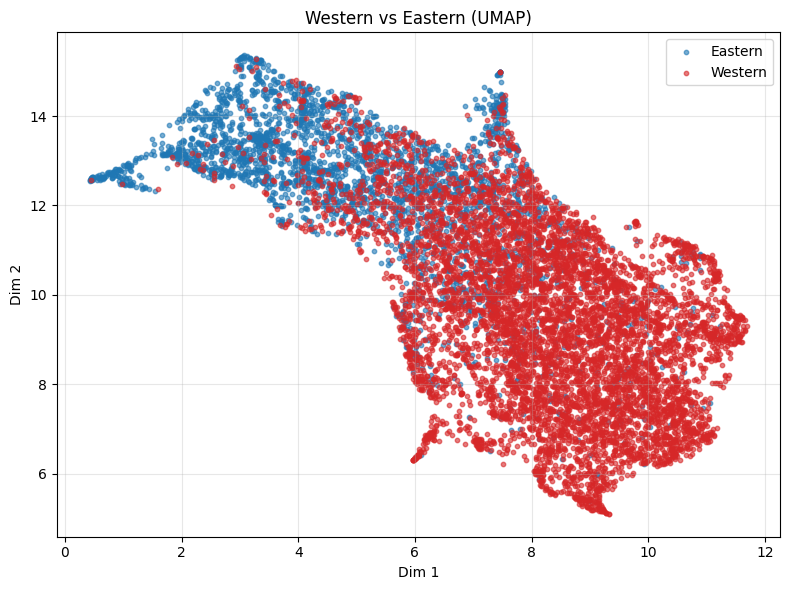

In [ ]:
import matplotlib.pyplot as plt

def plot_2d_embedding(emb_2d, labels, title="2D embedding"):
    """
    emb_2d: (N, 2)
    labels: (N,) with 0/1 (Eastern / Western) according to your ImageFolder
    """
    plt.figure(figsize=(8, 6))

    colors = ['#1f77b4', '#d62728']  # blue, red
    label_names = ['Eastern', 'Western']  # adjust if your class order is reversed

    for cls in [0, 1]:
        idx = np.where(labels == cls)[0]
        plt.scatter(
            emb_2d[idx, 0],
            emb_2d[idx, 1],
            s=10,
            alpha=0.6,
            c=colors[cls],
            label=label_names[cls]
        )

    plt.title(title)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_2d_embedding(emb_2d_umap, labels, title="Western vs Eastern (UMAP)")


### Interpretation of similarity score and UMAP plot

```
Centroid distance: 6.5057
Cross-cuisine similarity score: 0.1332
```

Although the centroid distance between Western and Eastern embeddings is large (6.51), indicating strong global separation in the model’s 1792-dimensional latent space, the UMAP visualization shows substantial overlap. This is expected because UMAP preserves local neighborhoods but distorts global geometry when projecting to 2D. The overlap suggests that many dishes share similar low-level visual cues (colors, textures, plating), while the global separation indicates that the model still learns cuisine-specific distinctions at a higher level.

In [ ]:
# -------------------------------------------------------
# TCAV - Load huggingface dataset
# -------------------------------------------------------

from datasets import load_dataset, load_from_disk

MMFOOD_DATA_DIR = os.path.join(PROJECT_PATH, "data/Codatta-MM-Food-100K")

if not os.path.exists(MMFOOD_DATA_DIR):
    os.makedirs(MMFOOD_DATA_DIR)

if not os.path.exists(os.path.join(MMFOOD_DATA_DIR, "train")):
    dataset = load_dataset("Codatta/MM-Food-100K")
    dataset.save_to_disk(MMFOOD_DATA_DIR)
    print("Dataset saved to", MMFOOD_DATA_DIR)
else:
    dataset = load_from_disk(MMFOOD_DATA_DIR)
    print("Dataset already exists at", MMFOOD_DATA_DIR)

train_ds = dataset["train"]
link = dataset["train"][0]["image_url"]
print(link)

Dataset already exists at /content/drive/MyDrive/CS5787_DL_Final_Project/data/Codatta-MM-Food-100K
https://file.b18a.io/7843322356500104680_443548_.jpeg


In [ ]:
# -------------------------------------------------------
# TCAV - Create mappings of concept to positive images and negative images
# -------------------------------------------------------
#
# Expect each concept entry to contain 50 pos image tensors and 50 neg image tensors
#
# concept_to_images = {
#     "noodle": {"pos": [...], "neg": [...]},
#     "tomato": {"pos": [...], "neg": [...]},
#     "rice": {"pos": [...], "neg": [...]},
#     "steak": {"pos": [...], "neg": [...]},
#     "spice": {"pos": [...], "neg": [...]},
# }

import requests
from io import BytesIO
from torchvision import transforms
import pickle

CONCEPT_TO_IMAGES_DIR = os.path.join(MMFOOD_DATA_DIR, "concept_to_images.pkl")

concept_to_images = {"noodle": {}, "tomato": {}, "rice": {}, "steak": {}, "spice": {}}

if os.path.exists(CONCEPT_TO_IMAGES_DIR):
    print("File exists. Try loading concept_to_images...")
    with open(CONCEPT_TO_IMAGES_DIR, "rb") as f:
        concept_to_images = pickle.load(f)
        print("Loaded concept_to_images from file.")
else:
    print(".pkl not exists so create a new one")
    CONCEPT_IMG_THRESHOLD = 50
    for _, v in concept_to_images.items():
        v["pos"] = [] # Collect 50 positive concept images
        v["neg"] = [] # Collect 50 negative concept images

    concept_tf = transforms.Compose([
        transforms.Resize(420),
        transforms.CenterCrop(380),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def load_image_from_url(url):
        """
        Load image from URL as a PIL.Image in RGB.
        Returns None if anything fails.
        """
        try:
            resp = requests.get(url, timeout=5)
            resp.raise_for_status()
            img = Image.open(BytesIO(resp.content)).convert("RGB")
            return img
        except Exception as e:
            print(f"  [WARN] Skipping {url}: {e}")
            return None

    for i, ex in enumerate(train_ds):
        ingredients = ex.get("ingredients")
        for concept, pn in concept_to_images.items():
            if len(pn["pos"]) < CONCEPT_IMG_THRESHOLD and concept in ingredients:
                img = load_image_from_url(ex["image_url"])
                pn["pos"].append(concept_tf(img))
            elif len(pn["neg"]) < CONCEPT_IMG_THRESHOLD and concept not in ingredients:
                img = load_image_from_url(ex["image_url"])
                pn["neg"].append(concept_tf(img))

        if all(
            len(imgs["pos"]) >= CONCEPT_IMG_THRESHOLD
            and len(imgs["neg"]) >= CONCEPT_IMG_THRESHOLD
            for imgs in concept_to_images.values()
        ):
            break

    with open(CONCEPT_TO_IMAGES_DIR, "wb") as f:
        pickle.dump(concept_to_images, f)
    print("Saved new pkl file at: ", CONCEPT_TO_IMAGES_DIR)


File exists. Try loading concept_to_images...
Loaded concept_to_images from file.


In [ ]:
print([(k, len(pn["pos"]), len(pn["neg"])) for k, pn in concept_to_images.items()])

[('noodle', 50, 50), ('tomato', 50, 50), ('rice', 50, 50), ('steak', 50, 50), ('spice', 50, 50)]


In [ ]:
model.to(device)
model.eval()

target_layer = model._conv_head   # layer for concept activations

In [ ]:
import torch
import numpy as np

def get_activations_for_images(model, target_layer, image_list, batch_size=16, device="cuda"):
    """
    image_list: list[Tensor(C, H, W)] already normalized like training data.
    returns: numpy array of shape [N, D]
    """
    model.eval()
    device = torch.device(device)
    activations = []

    # Local hook JUST for this function
    def activation_hook(module, input, output):
        # output: [B, C, H, W]
        gap = output.mean(dim=(2, 3))   # [B, C]
        activations.append(gap.detach().cpu())

    handle = target_layer.register_forward_hook(activation_hook)

    with torch.no_grad():
        for i in range(0, len(image_list), batch_size):
            batch_imgs = image_list[i:i + batch_size]
            if len(batch_imgs) == 0:
                continue
            batch = torch.stack(batch_imgs, dim=0).to(device)  # [B, C, H, W]
            _ = model(batch)

    handle.remove()  # VERY important

    if len(activations) == 0:
        return np.zeros((0, model._fc.in_features), dtype=np.float32)

    acts = torch.cat(activations, dim=0)  # [N, C, 1, 1]
    acts = acts.view(acts.size(0), -1)    # [N, C]
    return acts.numpy()


In [ ]:
from sklearn.svm import LinearSVC

concept_vectors = {}   # concept_name -> np.array([D])

for concept, img_dict in concept_to_images.items():
    pos_imgs = img_dict["pos"]   # list of tensors
    neg_imgs = img_dict["neg"]   # list of tensors

    print(f"Processing concept: {concept} | pos={len(pos_imgs)}, neg={len(neg_imgs)}")

    pos_feats = get_activations_for_images(model, target_layer, pos_imgs, device=device.type)
    neg_feats = get_activations_for_images(model, target_layer, neg_imgs, device=device.type)

    print(f"  pos_feats shape: {pos_feats.shape}, neg_feats shape: {neg_feats.shape}")

    if pos_feats.shape[0] == 0 or neg_feats.shape[0] == 0:
        print(f"  Skipping {concept}: not enough data.")
        continue

    X = np.vstack([pos_feats, neg_feats])              # [N_pos + N_neg, D]
    y = np.concatenate([
        np.ones(pos_feats.shape[0]),                   # 1 = concept present
        np.zeros(neg_feats.shape[0])                   # 0 = concept absent
    ])

    clf = LinearSVC(class_weight="balanced", max_iter=10000)
    clf.fit(X, y)

    # 4) Weight vector = concept direction
    w = clf.coef_[0]                                   # [D]
    w_norm = w / (np.linalg.norm(w) + 1e-8)           # normalize

    concept_vectors[concept] = w_norm
    print(f"  Learned concept vector for {concept}, dim={w_norm.shape[0]}")

print(concept_vectors.keys())

Processing concept: noodle | pos=50, neg=50
  pos_feats shape: (50, 1792), neg_feats shape: (50, 1792)
  Learned concept vector for noodle, dim=1792
Processing concept: tomato | pos=50, neg=50
  pos_feats shape: (50, 1792), neg_feats shape: (50, 1792)
  Learned concept vector for tomato, dim=1792
Processing concept: rice | pos=50, neg=50
  pos_feats shape: (50, 1792), neg_feats shape: (50, 1792)
  Learned concept vector for rice, dim=1792
Processing concept: steak | pos=50, neg=50
  pos_feats shape: (50, 1792), neg_feats shape: (50, 1792)
  Learned concept vector for steak, dim=1792
Processing concept: spice | pos=50, neg=50
  pos_feats shape: (50, 1792), neg_feats shape: (50, 1792)
  Learned concept vector for spice, dim=1792
dict_keys(['noodle', 'tomato', 'rice', 'steak', 'spice'])


In [ ]:
# Sanity check
print("  Train accuracy:", clf.score(X, y))

  Train accuracy: 1.0


In [ ]:
print("Classes:", test_dataset.classes)

EASTERN_IDX = 0
WESTERN_IDX = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

concept_vectors_torch = {
    name: torch.tensor(vec, dtype=torch.float32, device=device)
    for name, vec in concept_vectors.items()
}

layer_ctx = {}  # to store activations

def grad_hook(module, input, output):
    # output: [B, C, 1, 1]
    layer_ctx["acts"] = output
    output.retain_grad()   # we want grads w.r.t. this tensor

grad_handle = target_layer.register_forward_hook(grad_hook) # Remove hook at the end

Classes: ['Eastern', 'Western']


In [ ]:
def directional_derivatives_for_image(model, img, class_idx, concept_vectors_torch, device):
    """
    img: Tensor(C, H, W) – a single preprocessed image
    class_idx: int – WESTERN_IDX or EASTERN_IDX
    returns: dict[concept_name] -> float directional derivative
    """
    model.zero_grad()

    img = img.unsqueeze(0).to(device)   # [1, C, H, W]

    # forward WITH grad tracking (no torch.no_grad here)
    logits = model(img)                 # [1, 2]
    logit = logits[0, class_idx]        # scalar for the chosen class

    # backward from that logit
    logit.backward(retain_graph=False)

    # activations and gradients grabbed by hook
    acts = layer_ctx["acts"]          # [1, C, H, W]
    grads = acts.grad                 # [1, C, H, W]
    grads_flat = grads.mean(dim=(0, 2, 3))  # [C]

    derivs = {}
    for name, cvec in concept_vectors_torch.items():
        derivs[name] = torch.dot(grads_flat, cvec).item()
    return derivs

def compute_tcav_scores_for_class(model, images, class_idx, concept_vectors_torch, device):
    """
    images: list[Tensor(C,H,W)] from the same true class (Western or Eastern)
    returns: dict[concept_name] -> TCAV score in [0, 1]
    """
    counts_pos = {name: 0 for name in concept_vectors_torch.keys()}
    total = 0

    for img in images:
        derivs = directional_derivatives_for_image(
            model, img, class_idx, concept_vectors_torch, device
        )
        total += 1
        for name, val in derivs.items():
            if val > 0:   # concept direction increases the class logit
                counts_pos[name] += 1

    tcav_scores = {name: counts_pos[name] / total for name in counts_pos}
    return tcav_scores



In [ ]:
western_imgs_for_tcav = []
eastern_imgs_for_tcav = []
tcav_imgs_len = 50

print("Populating eastern/western imgs...")

for img, label in test_dataset:
    if label == EASTERN_IDX and len(eastern_imgs_for_tcav) < tcav_imgs_len:
        eastern_imgs_for_tcav.append(img)

    if len(eastern_imgs_for_tcav) >= tcav_imgs_len:
        break

for idx in range(len(test_dataset) - 1, -1, -1):
    img, label = test_dataset[idx]
    if label == WESTERN_IDX and len(western_imgs_for_tcav) < tcav_imgs_len:
        western_imgs_for_tcav.append(img)

    if len(western_imgs_for_tcav) >= tcav_imgs_len:
        break

print("Comuting TCAV for eastern/western dataset...")

western_tcav = compute_tcav_scores_for_class(
    model,
    western_imgs_for_tcav,
    WESTERN_IDX,
    concept_vectors_torch,
    device,
)

eastern_tcav = compute_tcav_scores_for_class(
    model,
    eastern_imgs_for_tcav,
    EASTERN_IDX,
    concept_vectors_torch,
    device,
)

print("Western TCAV:", western_tcav)
print("Eastern TCAV:", eastern_tcav)

grad_handle.remove()

Populating eastern/western imgs...
Comuting TCAV for eastern/western dataset...
Western TCAV: {'noodle': 0.8, 'tomato': 0.56, 'rice': 0.28, 'steak': 0.42, 'spice': 0.04}
Eastern TCAV: {'noodle': 0.84, 'tomato': 0.02, 'rice': 0.28, 'steak': 0.0, 'spice': 0.14}
